In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/students-performance-in-exams/StudentsPerformance.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

df = pd.read_csv("/kaggle/input/students-performance-in-exams/StudentsPerformance.csv")

In [3]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
race_count = df['race/ethnicity'].value_counts()
race_count

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

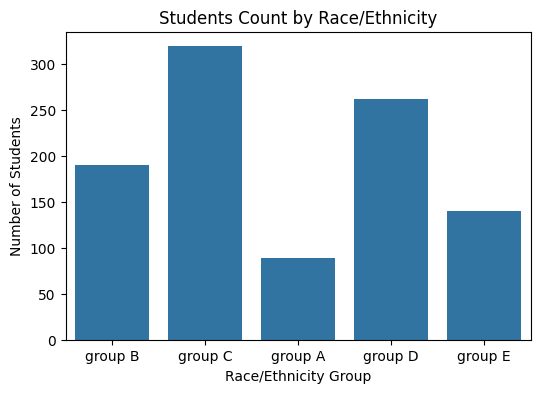

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='race/ethnicity', data = df)
plt.title('Students Count by Race/Ethnicity')
plt.xlabel('Race/Ethnicity Group')
plt.ylabel('Number of Students')
plt.show()

In [7]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [8]:
low_score_student = df[(df['math score']<50) | (df['reading score']<50) | (df['writing score']<50)]
print(low_score_student)

     gender race/ethnicity parental level of education         lunch  \
3      male        group A          associate's degree  free/reduced   
7      male        group B                some college  free/reduced   
9    female        group B                 high school  free/reduced   
11     male        group D          associate's degree      standard   
17   female        group B            some high school  free/reduced   
..      ...            ...                         ...           ...   
973  female        group D                some college  free/reduced   
978    male        group D                 high school      standard   
980  female        group B                 high school  free/reduced   
986  female        group C          associate's degree      standard   
988  female        group A            some high school  free/reduced   

    test preparation course  math score  reading score  writing score  
3                      none          47             57         

In [9]:
print(df.groupby('gender')[['math score','reading score','writing score']].mean())

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


In [10]:
print(df.groupby("race/ethnicity")[['math score','reading score','writing score']].mean())

                math score  reading score  writing score
race/ethnicity                                          
group A          61.629213      64.674157      62.674157
group B          63.452632      67.352632      65.600000
group C          64.463950      69.103448      67.827586
group D          67.362595      70.030534      70.145038
group E          73.821429      73.028571      71.407143


In [11]:
print(df.groupby("parental level of education")[['math score','reading score','writing score']].mean())

                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some college                  67.128319      69.460177      68.840708
some high school              63.497207      66.938547      64.888268


In [12]:
print(df.groupby("test preparation course")[['math score','reading score','writing score']].mean())

                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673


In [13]:
low_score = df[(df["math score"]<60) | (df["reading score"]<60) | (df["writing score"]<60)]
print(low_score[['math score','reading score','writing score']].mean())

math score       52.108312
reading score    55.911839
writing score    54.357683
dtype: float64


# Data Cleaning

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [16]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [17]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


# Exploratory Data Analysis (EDA)

**Step 1: Univariate Analysis**

In [18]:
print("\n Gender Count: \n", df['gender'].value_counts())


 Gender Count: 
 gender
female    518
male      482
Name: count, dtype: int64


In [19]:
print("\n Race Count: \n", df['race/ethnicity'].value_counts())


 Race Count: 
 race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64


In [20]:
print("\nParental education counts:\n", df['parental level of education'].value_counts())


Parental education counts:
 parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


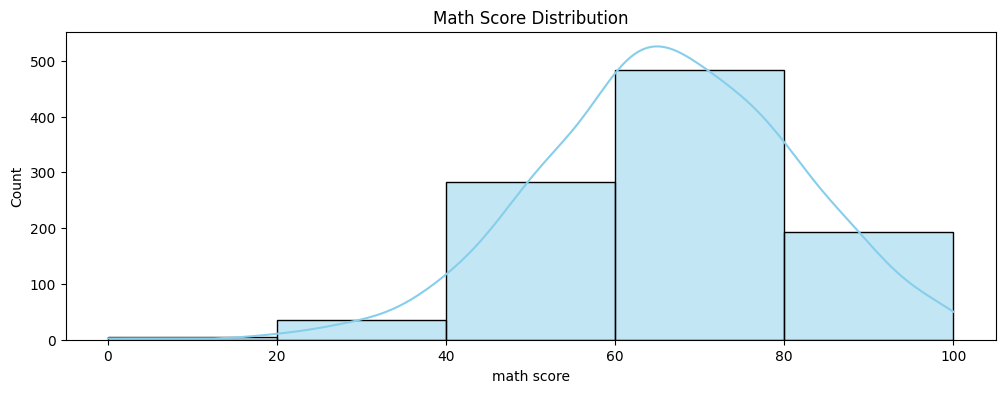

In [21]:
plt.figure(figsize=(12,4))
sns.histplot(df['math score'], kde=True, color='skyblue', bins=5)
plt.title('Math Score Distribution')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

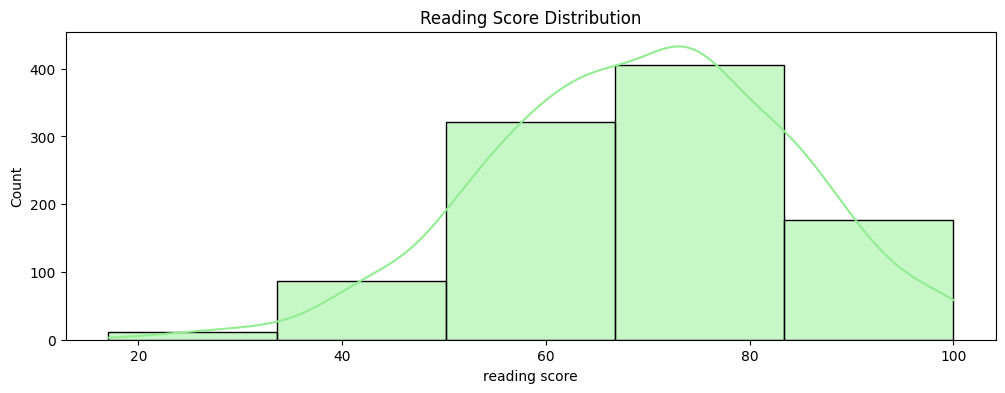

In [22]:
plt.figure(figsize=(12,4))
sns.histplot(df['reading score'], kde=True, color='lightgreen', bins=5)
plt.title("Reading Score Distribution")
plt.show

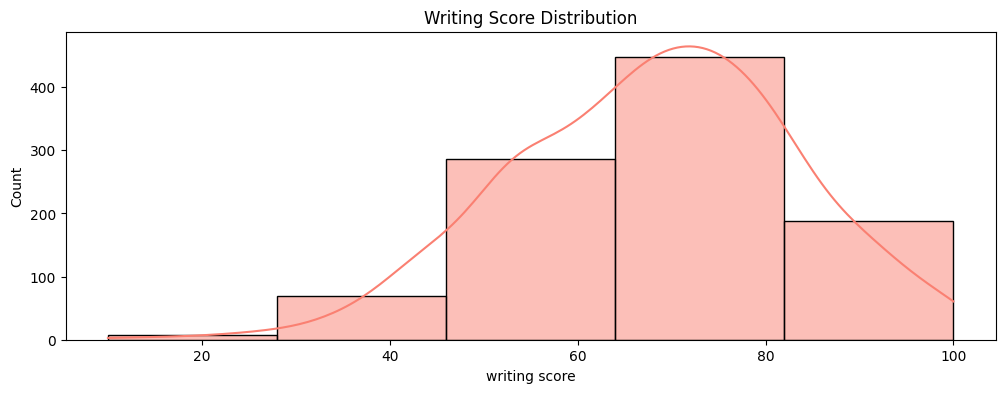

In [23]:

plt.figure(figsize=(12,4))
sns.histplot(df['writing score'], kde=True, color='salmon', bins=5)
plt.title('Writing Score Distribution')
plt.show()


In [24]:
print("\n Average Score by Gender \n", df.groupby("gender")[['math score','reading score','writing score']].mean())


 Average Score by Gender 
         math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


In [25]:
print(df.groupby("parental level of education")[['math score','reading score','writing score']].mean())

                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some college                  67.128319      69.460177      68.840708
some high school              63.497207      66.938547      64.888268


In [26]:
print(df.groupby("race/ethnicity")[['math score','reading score','writing score']].mean())

                math score  reading score  writing score
race/ethnicity                                          
group A          61.629213      64.674157      62.674157
group B          63.452632      67.352632      65.600000
group C          64.463950      69.103448      67.827586
group D          67.362595      70.030534      70.145038
group E          73.821429      73.028571      71.407143


In [27]:
corr = df[['math score','reading score','writing score']].corr()
print("\n Score Correlation \n", corr)


 Score Correlation 
                math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


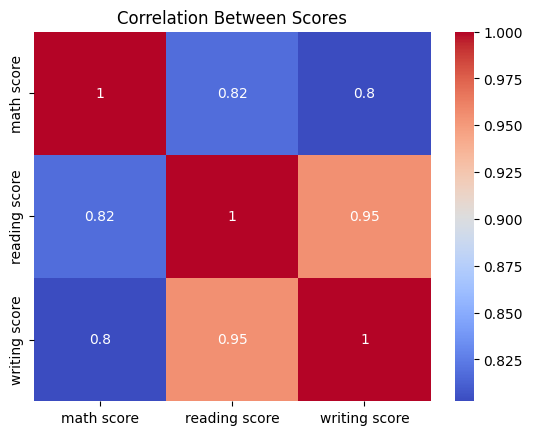

In [28]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Scores')
plt.show()

In [29]:
low_score = df[(df['math score']<60) | (df['reading score']<60) | (df['writing score']<60)]
print("\nLow scoring students:\n", low_score)


Low scoring students:
      gender race/ethnicity parental level of education         lunch  \
3      male        group A          associate's degree  free/reduced   
7      male        group B                some college  free/reduced   
9    female        group B                 high school  free/reduced   
10     male        group C          associate's degree      standard   
11     male        group D          associate's degree      standard   
..      ...            ...                         ...           ...   
986  female        group C          associate's degree      standard   
988  female        group A            some high school  free/reduced   
992  female        group D          associate's degree  free/reduced   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   

    test preparation course  math score  reading score  writing score  
3                      none          47

# BASIC FEATURES ENGINEERING

In [30]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [31]:
df['total score'] = df['math score']+df['reading score']+df['writing score']

In [32]:
df[['math score','reading score','writing score','total score']].head(3)

,math score,reading score,writing score,total score
0,72,72,74,218
1,69,90,88,247
2,90,95,93,278


In [33]:
df["average score"] = df[['math score','reading score', 'writing score']].mean(axis=1)
df['average score'].head(3)

0    72.666667
1    82.333333
2    92.666667
Name: average score, dtype: float64

In [34]:
def performence_label(avg):
    if avg < 60:
        return "Low"
    elif avg < 80:
        return "Medium"
    else:
        return "High"
df['performence level'] = df['average score'].apply(performence_label)
df[['average score','performence level']].head()

,average score,performence level
0,72.666667,Medium
1,82.333333,High
2,92.666667,High
3,49.333333,Low
4,76.333333,Medium


In [35]:
df["test preparation course"].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

In [36]:
df['test_prep_completed'] = df["test preparation course"].map({"completed":1,'none':0})
df[['test preparation course','test_prep_completed']].head()

,test preparation course,test_prep_completed
0,none,0
1,completed,1
2,none,0
3,none,0
4,none,0


In [37]:
df['weak_subject'] = df[['math score','reading score','writing score']].idxmin(axis=1)
df[['math score','reading score','writing score','weak_subject']].head()


,math score,reading score,writing score,weak_subject
0,72,72,74,math score
1,69,90,88,math score
2,90,95,93,math score
3,47,57,44,writing score
4,76,78,75,writing score


# Final DataSet visualization 

In [38]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'total score', 'average score', 'performence level',
       'test_prep_completed', 'weak_subject'],
      dtype='object')

In [39]:
print("Total Student: ", df.shape[0])
print("Average Score (OverAll): ", round(df['average score'].mean(), 2))
print("Low Performance: ", (df['performence level'] == "Low").sum())

Total Student:  1000
Average Score (OverAll):  67.77
Low Performance:  285
